# In this script we will do Data exploration and Data cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

An important thing has to be mentioned. To do the data exploration process, I used Data Wrangler, an extension from VsCode which is so usefull for this part of the analysis. Because of that, all of the data exploring process has been done using It.

In [2]:
df = pd.read_csv(r'C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\data_analysis_2\classic_machine_learning\DataSet.csv')
df

,Unnamed: 0,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,change,diabetesMed,readmitted
0,0,41186889,Caucasian,Female,[80-90),1,6,7,13,69,...,No,No,Steady,Steady,No,No,No,No,Yes,NO
1,1,83591073,Caucasian,Female,[80-90),6,1,17,5,34,...,No,No,Steady,No,No,No,No,No,No,NO
2,2,68337009,Other,Male,[60-70),1,2,1,1,37,...,No,No,Steady,Steady,No,No,No,No,Yes,NO
3,3,73175076,Caucasian,Male,[40-50),1,1,7,4,56,...,No,No,Steady,Up,No,No,No,Ch,Yes,YES
4,4,31718349,Caucasian,Female,[70-80),1,1,7,1,38,...,No,No,Steady,No,No,No,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,6316443,Caucasian,Female,[80-90),1,1,7,3,47,...,No,No,Steady,No,No,No,No,Ch,Yes,YES
4996,4996,96364728,Caucasian,Male,[70-80),2,1,1,8,52,...,No,No,Steady,No,No,No,No,Ch,Yes,YES
4997,4997,101621745,Caucasian,Male,[50-60),1,1,2,1,17,...,No,No,Steady,Steady,No,No,No,Ch,Yes,NO
4998,4998,21969333,Caucasian,Male,[70-80),1,1,7,2,42,...,No,No,No,No,No,No,No,No,Yes,YES


In [3]:
# Extract column names and their data types
columns = df.dtypes.reset_index()
columns.columns = ['Feature', 'Data Type']

# Convert the data types to a more readable format
columns['Data Type'] = columns['Data Type'].apply(lambda x: 'Integer' if x == 'int64' else 'Float' if x == 'float64' else 'Object')

# Generate LaTeX table
latex_table = columns.to_latex(index=False, caption="Features and Their Data Types", label="tab:features_data_types")
print(latex_table)

\begin{table}
\caption{Features and Their Data Types}
\label{tab:features_data_types}
\begin{tabular}{ll}
\toprule
Feature & Data Type \\
\midrule
Unnamed: 0 & Integer \\
patient_nbr & Integer \\
race & Object \\
gender & Object \\
age & Object \\
admission_type_id & Integer \\
discharge_disposition_id & Integer \\
admission_source_id & Integer \\
time_in_hospital & Integer \\
num_lab_procedures & Integer \\
num_procedures & Integer \\
num_medications & Integer \\
number_outpatient & Integer \\
number_emergency & Integer \\
number_inpatient & Integer \\
diag_1 & Float \\
diag_2 & Float \\
diag_3 & Float \\
diag_4 & Float \\
number_diagnoses & Integer \\
chlorpropamide & Object \\
glimepiride & Object \\
acetohexamide & Object \\
glyburide & Object \\
tolbutamide & Object \\
pioglitazone & Object \\
rosiglitazone & Object \\
troglitazone & Object \\
tolazamide & Object \\
examide & Object \\
citoglipton & Object \\
insulin & Object \\
glyburide-metformin & Object \\
glipizide-metformin 

In [4]:
df.describe()

,Unnamed: 0,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,diag_4,number_diagnoses
count,5000.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,5.422552e+07,2.03220,3.700400,5.704000,4.430400,43.195200,1.360400,15.904600,0.417600,0.187200,0.638000,482.745440,439.625244,414.914594,439.815457,7.395000
std,1443.520003,3.849572e+07,1.45643,5.265148,3.951393,3.009612,19.761316,1.711227,8.117406,1.476227,0.755957,1.244374,209.822249,189.521997,199.994923,213.940968,1.925647
min,0.000000,5.220000e+03,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5.000000,8.000000,8.000000,5.151678,1.000000
25%,1249.750000,2.340186e+07,1.00000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,403.000000,276.000000,250.920000,287.300363,6.000000
50%,2499.500000,4.534128e+07,1.00000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,435.000000,426.000000,403.000000,409.086176,8.000000
75%,3749.250000,8.722371e+07,3.00000,3.250000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,590.000000,560.000000,511.000000,552.748089,9.000000
max,4999.000000,1.892989e+08,8.00000,28.000000,20.000000,14.000000,108.000000,6.000000,65.000000,39.000000,22.000000,15.000000,999.000000,999.000000,998.000000,1509.286492,16.000000


We first look at the id mapping for the features diag_1, diag_2, diag_3, admission_type_id, discharge_position_id and admission_source_id

In [ ]:
# ID_mappings
df['admission_type_id'] = df['admission_type_id'].replace(
    {
        1: "emergency",
        2: "emergency",
        7: "emergency",


        3: "elective",


        4: "newborn",


        5: np.nan,
        6: np.nan,
        8: np.nan,
    }
)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(
    {
        1: "home",
        6: "home",
        8: "home",


        11: "expired",


        13: "hospice",
        14: "hospice",


        2: "hospital",
        3: "hospital",
        4: "hospital",
        5: "hospital",
        7: "hospital",
        9: "hospital",
        10: "hospital",
        15: "hospital",
        16: "hospital",
        17: "hospital",
        22: "hospital",
        23: "hospital",
        24: "hospital",
        27: "hospital",
        28: "hospital",
        29: "hospital",


        18: np.nan,
        25: np.nan,
        26: np.nan
    }
)


df['admission_source_id'] = df['admission_source_id'].replace(
    {

        1: "referral",
        2: "referral",
        3: "referral",


        4: "transfer",
        5: "transfer",
        6: "transfer",
        10: "transfer",
        18: "transfer",
        22: "transfer",
        25: "transfer",
        26: "transfer",


        7: "emergency",
        8: "law_enforcement",


        11: "birth",
        12: "birth",
        13: "birth",
        14: "birth",
        23: "birth",
        24: "birth",


        19: "readmission",


        9: np.nan,
        15: np.nan,
        17: np.nan,
        20: np.nan,
        21: np.nan
    }
)

diag_list = ['diag_1', 'diag_2', 'diag_3']
for diag in diag_list: 
    df[diag] = np.where(df[diag].between(390, 459), 1, df[diag])
    df[diag] = np.where(df[diag].between(785, 785), 1, df[diag])

    df[diag] = np.where(df[diag].between(460, 519), 2, df[diag])
    df[diag] = np.where(df[diag].between(786, 786), 2, df[diag])

    df[diag] = np.where(df[diag].between(520, 579), 3, df[diag])
    df[diag] = np.where(df[diag].between(787, 787), 3, df[diag])

    df[diag] = np.where(df[diag].between(250,250.99), 4, df[diag])

    df[diag] = np.where(df[diag].between(800, 999), 5, df[diag])

    df[diag] = np.where(df[diag].between(710, 739), 6, df[diag])

    df[diag] = np.where(df[diag].between(580, 629), 7, df[diag])
    df[diag] = np.where(df[diag].between(788, 788), 7, df[diag])

    df[diag] = np.where(df[diag].between(140, 239), 8, df[diag])


    df[diag] = np.where(~df[diag].isin([1, 2, 3, 4, 5, 6, 7, 8]), 9, df[diag])

    df[diag] = df[diag].replace(
    {
        1: "circulatory", 
        2: "respiratory",
        3: "digestive", 
        4: "diabetes",
        5: "injury",
        6: "musculoskeletal",
        7: "genitourinary", 
        8: "neoplasms",
        9: "other",
    }
)


In [ ]:

decoding_data = {
    'Feature': ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1, diag_2, diag_3'],
    'Original Values': [
        '{1, 2, 7: emergency; 3: elective; 4: newborn; 5, 6, 8: NaN}',
        '{1, 6, 8: home; 11: expired; 13, 14: hospice; 2, 3, 4, 5, 7, 9, 10, 15-29: hospital; 18, 25, 26: NaN}',
        '{1, 2, 3: referral; 4, 5, 6, 10, 18, 22, 25, 26: transfer; 7: emergency; 8: law_enforcement; 11-14, 23, 24: birth; 19: readmission; 9, 15, 17, 20, 21: NaN}',
        '{390-459, 785: circulatory; 460-519, 786: respiratory; 520-579, 787: digestive; 250-250.99: diabetes; 800-999: injury; 710-739: musculoskeletal; 580-629, 788: genitourinary; 140-239: neoplasms; others: other}'
    ]
}

decoding_df = pd.DataFrame(decoding_data)

#LaTeX table
latex_decoding_table = decoding_df.to_latex(index=False, caption="Decoding Process for Features", label="tab:decoding_process")
print(latex_decoding_table)

\begin{table}
\caption{Decoding Process for Features}
\label{tab:decoding_process}
\begin{tabular}{ll}
\toprule
Feature & Original Values \\
\midrule
admission_type_id & {1, 2, 7: emergency; 3: elective; 4: newborn; 5, 6, 8: NaN} \\
discharge_disposition_id & {1, 6, 8: home; 11: expired; 13, 14: hospice; 2, 3, 4, 5, 7, 9, 10, 15-29: hospital; 18, 25, 26: NaN} \\
admission_source_id & {1, 2, 3: referral; 4, 5, 6, 10, 18, 22, 25, 26: transfer; 7: emergency; 8: law_enforcement; 11-14, 23, 24: birth; 19: readmission; 9, 15, 17, 20, 21: NaN} \\
diag_1, diag_2, diag_3 & {390-459, 785: circulatory; 460-519, 786: respiratory; 520-579, 787: digestive; 250-250.99: diabetes; 800-999: injury; 710-739: musculoskeletal; 580-629, 788: genitourinary; 140-239: neoplasms; others: other} \\
\bottomrule
\end{tabular}
\end{table}



diag_4 seems different to the previous diagnosis, having icd9 bigger than the maximum stablished in the article. Moreover, if one looks at the distribution of data seems very different to the other diagnosis columns. I will leave it for now and see if it is a good idea to eliminate it on while doing feature selection

Another strange feature which is very strange is citoglipton because is not mentioned on the paper. Nevertheless, I will leave it for now and see how important is when doing the feature selection

Now we would like or to make al ? $\to$  NaN

In [5]:
df.replace('?', np.nan, inplace=True)

In [6]:
df

,Unnamed: 0,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,change,diabetesMed,readmitted
0,0,41186889,Caucasian,Female,[80-90),emergency,home,emergency,13,69,...,No,No,Steady,Steady,No,No,No,No,Yes,NO
1,1,83591073,Caucasian,Female,[80-90),NaN,home,NaN,5,34,...,No,No,Steady,No,No,No,No,No,No,NO
2,2,68337009,Other,Male,[60-70),emergency,hospital,referral,1,37,...,No,No,Steady,Steady,No,No,No,No,Yes,NO
3,3,73175076,Caucasian,Male,[40-50),emergency,home,emergency,4,56,...,No,No,Steady,Up,No,No,No,Ch,Yes,YES
4,4,31718349,Caucasian,Female,[70-80),emergency,home,emergency,1,38,...,No,No,Steady,No,No,No,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,6316443,Caucasian,Female,[80-90),emergency,home,emergency,3,47,...,No,No,Steady,No,No,No,No,Ch,Yes,YES
4996,4996,96364728,Caucasian,Male,[70-80),emergency,home,referral,8,52,...,No,No,Steady,No,No,No,No,Ch,Yes,YES
4997,4997,101621745,Caucasian,Male,[50-60),emergency,home,referral,1,17,...,No,No,Steady,Steady,No,No,No,Ch,Yes,NO
4998,4998,21969333,Caucasian,Male,[70-80),emergency,home,emergency,2,42,...,No,No,No,No,No,No,No,No,Yes,YES


Now, we will eliminate different features

In [7]:
columns_to_remove = [
    'Unnamed: 0',
    'chlorpropamide', 'glimepiride', 'acetohexamide', 'tolbutamide', 
    'pioglitazone', 'rosiglitazone', 'troglitazone', 'tolazamide', 
    'examide', 'glyburide-metformin', 'glipizide-metformin', 
    'metformin-rosiglitazone'
]
df.drop(columns=columns_to_remove, inplace=True)

All of these medications have above $90\%$ No, so I decided to eliminate them because they very unbalanced. On the other hand, tolbutamide had an $80\%$ of missing values, so I decided to also eliminate it.

On the other hand, Unnamed 0 does not give any information apart from being the row number

In [8]:
df

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,diag_2,diag_3,diag_4,number_diagnoses,glyburide,citoglipton,insulin,change,diabetesMed,readmitted
0,41186889,Caucasian,Female,[80-90),emergency,home,emergency,13,69,4,...,injury,injury,764.938726,9,No,Steady,Steady,No,Yes,NO
1,83591073,Caucasian,Female,[80-90),NaN,home,NaN,5,34,0,...,neoplasms,circulatory,289.692993,7,No,Steady,No,No,No,NO
2,68337009,Other,Male,[60-70),emergency,hospital,referral,1,37,1,...,diabetes,circulatory,261.207404,5,No,Steady,Steady,No,Yes,NO
3,73175076,Caucasian,Male,[40-50),emergency,home,emergency,4,56,2,...,diabetes,genitourinary,239.239855,9,No,Steady,Up,Ch,Yes,YES
4,31718349,Caucasian,Female,[70-80),emergency,home,emergency,1,38,2,...,injury,digestive,447.777469,7,No,Steady,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,Caucasian,Female,[80-90),emergency,home,emergency,3,47,3,...,circulatory,genitourinary,436.278826,6,Down,Steady,No,Ch,Yes,YES
4996,96364728,Caucasian,Male,[70-80),emergency,home,referral,8,52,0,...,other,other,100.470643,9,Up,Steady,No,Ch,Yes,YES
4997,101621745,Caucasian,Male,[50-60),emergency,home,referral,1,17,0,...,other,circulatory,252.534331,9,Steady,Steady,Steady,Ch,Yes,NO
4998,21969333,Caucasian,Male,[70-80),emergency,home,emergency,2,42,6,...,circulatory,circulatory,490.513630,8,No,No,No,No,Yes,YES


Because we have a little amount of data, instead of eliminating all NaN, we will substitute them with some random value picked from the column, so It will, at least approximetly, follow the same probability distribution of that feature.

In [ ]:
#Replace NaN values in each column based on the column's value distribution
for column in df.columns:
    if df[column].isnull().any():
        df[column] = df[column].apply(lambda x: np.random.choice(df[column].dropna()) if pd.isnull(x) else x)

In [10]:
df

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,diag_2,diag_3,diag_4,number_diagnoses,glyburide,citoglipton,insulin,change,diabetesMed,readmitted
0,41186889,Caucasian,Female,[80-90),emergency,home,emergency,13,69,4,...,injury,injury,764.938726,9,No,Steady,Steady,No,Yes,NO
1,83591073,Caucasian,Female,[80-90),emergency,home,emergency,5,34,0,...,neoplasms,circulatory,289.692993,7,No,Steady,No,No,No,NO
2,68337009,Other,Male,[60-70),emergency,hospital,referral,1,37,1,...,diabetes,circulatory,261.207404,5,No,Steady,Steady,No,Yes,NO
3,73175076,Caucasian,Male,[40-50),emergency,home,emergency,4,56,2,...,diabetes,genitourinary,239.239855,9,No,Steady,Up,Ch,Yes,YES
4,31718349,Caucasian,Female,[70-80),emergency,home,emergency,1,38,2,...,injury,digestive,447.777469,7,No,Steady,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,Caucasian,Female,[80-90),emergency,home,emergency,3,47,3,...,circulatory,genitourinary,436.278826,6,Down,Steady,No,Ch,Yes,YES
4996,96364728,Caucasian,Male,[70-80),emergency,home,referral,8,52,0,...,other,other,100.470643,9,Up,Steady,No,Ch,Yes,YES
4997,101621745,Caucasian,Male,[50-60),emergency,home,referral,1,17,0,...,other,circulatory,252.534331,9,Steady,Steady,Steady,Ch,Yes,NO
4998,21969333,Caucasian,Male,[70-80),emergency,home,emergency,2,42,6,...,circulatory,circulatory,490.513630,8,No,No,No,No,Yes,YES


Do I eliminate all patients with some NaN????

In [11]:
df.dropna(inplace=True)

In [12]:
df

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,diag_2,diag_3,diag_4,number_diagnoses,glyburide,citoglipton,insulin,change,diabetesMed,readmitted
0,41186889,Caucasian,Female,[80-90),emergency,home,emergency,13,69,4,...,injury,injury,764.938726,9,No,Steady,Steady,No,Yes,NO
1,83591073,Caucasian,Female,[80-90),emergency,home,emergency,5,34,0,...,neoplasms,circulatory,289.692993,7,No,Steady,No,No,No,NO
2,68337009,Other,Male,[60-70),emergency,hospital,referral,1,37,1,...,diabetes,circulatory,261.207404,5,No,Steady,Steady,No,Yes,NO
3,73175076,Caucasian,Male,[40-50),emergency,home,emergency,4,56,2,...,diabetes,genitourinary,239.239855,9,No,Steady,Up,Ch,Yes,YES
4,31718349,Caucasian,Female,[70-80),emergency,home,emergency,1,38,2,...,injury,digestive,447.777469,7,No,Steady,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,Caucasian,Female,[80-90),emergency,home,emergency,3,47,3,...,circulatory,genitourinary,436.278826,6,Down,Steady,No,Ch,Yes,YES
4996,96364728,Caucasian,Male,[70-80),emergency,home,referral,8,52,0,...,other,other,100.470643,9,Up,Steady,No,Ch,Yes,YES
4997,101621745,Caucasian,Male,[50-60),emergency,home,referral,1,17,0,...,other,circulatory,252.534331,9,Steady,Steady,Steady,Ch,Yes,NO
4998,21969333,Caucasian,Male,[70-80),emergency,home,emergency,2,42,6,...,circulatory,circulatory,490.513630,8,No,No,No,No,Yes,YES


In [13]:
df['admission_type_id'].unique()

array(['emergency', 'elective'], dtype=object)

In [14]:
df['race'].unique()

array(['Caucasian', 'Other', 'Hispanic', 'AfricanAmerican', 'Asian'],
      dtype=object)

In [15]:
df['discharge_disposition_id'].unique()

array(['home', 'hospital', 'hospice', 'expired'], dtype=object)

In [16]:
df['admission_source_id'].unique()

array(['emergency', 'referral', 'transfer', 'birth'], dtype=object)

After some cleaning, I decided to reduce the possible values of features: race, discharge_disposition_id, admission_source_id.

- Hispanic and Asian $\to$ Other, because these three combined just are $4\%$ of all the dataset.
- hospice and expired $\to$ Other. Here I decided to merge both categories because both combined form just $3\%$
- transfer and birth $\to$ Other. Here I decided to merge both categories because birth was just less than $1\%$ and transfer formed just $6\%$ of the dataset.

In [17]:
df['race'] = df['race'].replace(['Hispanic', 'Asian'], 'Other')
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(['hospice', 'expired'], 'Other')
df['admission_source_id'] = df['admission_source_id'].replace(['transfer', 'birth'], 'Other')

In [18]:
df

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,diag_2,diag_3,diag_4,number_diagnoses,glyburide,citoglipton,insulin,change,diabetesMed,readmitted
0,41186889,Caucasian,Female,[80-90),emergency,home,emergency,13,69,4,...,injury,injury,764.938726,9,No,Steady,Steady,No,Yes,NO
1,83591073,Caucasian,Female,[80-90),emergency,home,emergency,5,34,0,...,neoplasms,circulatory,289.692993,7,No,Steady,No,No,No,NO
2,68337009,Other,Male,[60-70),emergency,hospital,referral,1,37,1,...,diabetes,circulatory,261.207404,5,No,Steady,Steady,No,Yes,NO
3,73175076,Caucasian,Male,[40-50),emergency,home,emergency,4,56,2,...,diabetes,genitourinary,239.239855,9,No,Steady,Up,Ch,Yes,YES
4,31718349,Caucasian,Female,[70-80),emergency,home,emergency,1,38,2,...,injury,digestive,447.777469,7,No,Steady,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,Caucasian,Female,[80-90),emergency,home,emergency,3,47,3,...,circulatory,genitourinary,436.278826,6,Down,Steady,No,Ch,Yes,YES
4996,96364728,Caucasian,Male,[70-80),emergency,home,referral,8,52,0,...,other,other,100.470643,9,Up,Steady,No,Ch,Yes,YES
4997,101621745,Caucasian,Male,[50-60),emergency,home,referral,1,17,0,...,other,circulatory,252.534331,9,Steady,Steady,Steady,Ch,Yes,NO
4998,21969333,Caucasian,Male,[70-80),emergency,home,emergency,2,42,6,...,circulatory,circulatory,490.513630,8,No,No,No,No,Yes,YES


Voy a convertir la columna age en valores del 0 al 0.9

In [ ]:
#Map the age ranges to values between 0 and 0.9
age_mapping = {
    '[0-10)': 0.0,
    '[10-20)': 0.1,
    '[20-30)': 0.2,
    '[30-40)': 0.3,
    '[40-50)': 0.4,
    '[50-60)': 0.5,
    '[60-70)': 0.6,
    '[70-80)': 0.7,
    '[80-90)': 0.8,
    '[90-100)': 0.9
}

df['age'] = df['age'].map(age_mapping)

In [20]:
df

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,diag_2,diag_3,diag_4,number_diagnoses,glyburide,citoglipton,insulin,change,diabetesMed,readmitted
0,41186889,Caucasian,Female,0.8,emergency,home,emergency,13,69,4,...,injury,injury,764.938726,9,No,Steady,Steady,No,Yes,NO
1,83591073,Caucasian,Female,0.8,emergency,home,emergency,5,34,0,...,neoplasms,circulatory,289.692993,7,No,Steady,No,No,No,NO
2,68337009,Other,Male,0.6,emergency,hospital,referral,1,37,1,...,diabetes,circulatory,261.207404,5,No,Steady,Steady,No,Yes,NO
3,73175076,Caucasian,Male,0.4,emergency,home,emergency,4,56,2,...,diabetes,genitourinary,239.239855,9,No,Steady,Up,Ch,Yes,YES
4,31718349,Caucasian,Female,0.7,emergency,home,emergency,1,38,2,...,injury,digestive,447.777469,7,No,Steady,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,Caucasian,Female,0.8,emergency,home,emergency,3,47,3,...,circulatory,genitourinary,436.278826,6,Down,Steady,No,Ch,Yes,YES
4996,96364728,Caucasian,Male,0.7,emergency,home,referral,8,52,0,...,other,other,100.470643,9,Up,Steady,No,Ch,Yes,YES
4997,101621745,Caucasian,Male,0.5,emergency,home,referral,1,17,0,...,other,circulatory,252.534331,9,Steady,Steady,Steady,Ch,Yes,NO
4998,21969333,Caucasian,Male,0.7,emergency,home,emergency,2,42,6,...,circulatory,circulatory,490.513630,8,No,No,No,No,Yes,YES


In [21]:
nominal_features = ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2', 'diag_3','citoglipton', 'glyburide', 'insulin', 'change', 'diabetesMed', 'readmitted']
df_extra = pd.get_dummies(df, columns=nominal_features, drop_first=True)
df_extra

,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_4,...,citoglipton_Steady,glyburide_No,glyburide_Steady,glyburide_Up,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,readmitted_YES
0,41186889,0.8,13,69,4,38,0,0,1,764.938726,...,True,True,False,False,False,True,False,True,True,False
1,83591073,0.8,5,34,0,4,0,0,0,289.692993,...,True,True,False,False,True,False,False,True,False,False
2,68337009,0.6,1,37,1,13,3,0,0,261.207404,...,True,True,False,False,False,True,False,True,True,False
3,73175076,0.4,4,56,2,22,0,0,0,239.239855,...,True,True,False,False,False,False,True,False,True,True
4,31718349,0.7,1,38,2,1,0,1,2,447.777469,...,True,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,0.8,3,47,3,8,0,0,0,436.278826,...,True,False,False,False,True,False,False,False,True,True
4996,96364728,0.7,8,52,0,17,2,0,0,100.470643,...,True,False,False,True,True,False,False,False,True,True
4997,101621745,0.5,1,17,0,11,0,0,0,252.534331,...,True,False,True,False,False,True,False,False,True,False
4998,21969333,0.7,2,42,6,12,0,0,0,490.513630,...,False,True,False,False,True,False,False,True,True,True


In [23]:
df_extra

,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_4,...,citoglipton_Steady,glyburide_No,glyburide_Steady,glyburide_Up,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,readmitted_YES
0,41186889,0.8,13,69,4,38,0,0,1,764.938726,...,True,True,False,False,False,True,False,True,True,False
1,83591073,0.8,5,34,0,4,0,0,0,289.692993,...,True,True,False,False,True,False,False,True,False,False
2,68337009,0.6,1,37,1,13,3,0,0,261.207404,...,True,True,False,False,False,True,False,True,True,False
3,73175076,0.4,4,56,2,22,0,0,0,239.239855,...,True,True,False,False,False,False,True,False,True,True
4,31718349,0.7,1,38,2,1,0,1,2,447.777469,...,True,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,0.8,3,47,3,8,0,0,0,436.278826,...,True,False,False,False,True,False,False,False,True,True
4996,96364728,0.7,8,52,0,17,2,0,0,100.470643,...,True,False,False,True,True,False,False,False,True,True
4997,101621745,0.5,1,17,0,11,0,0,0,252.534331,...,True,False,True,False,False,True,False,False,True,False
4998,21969333,0.7,2,42,6,12,0,0,0,490.513630,...,False,True,False,False,True,False,False,True,True,True


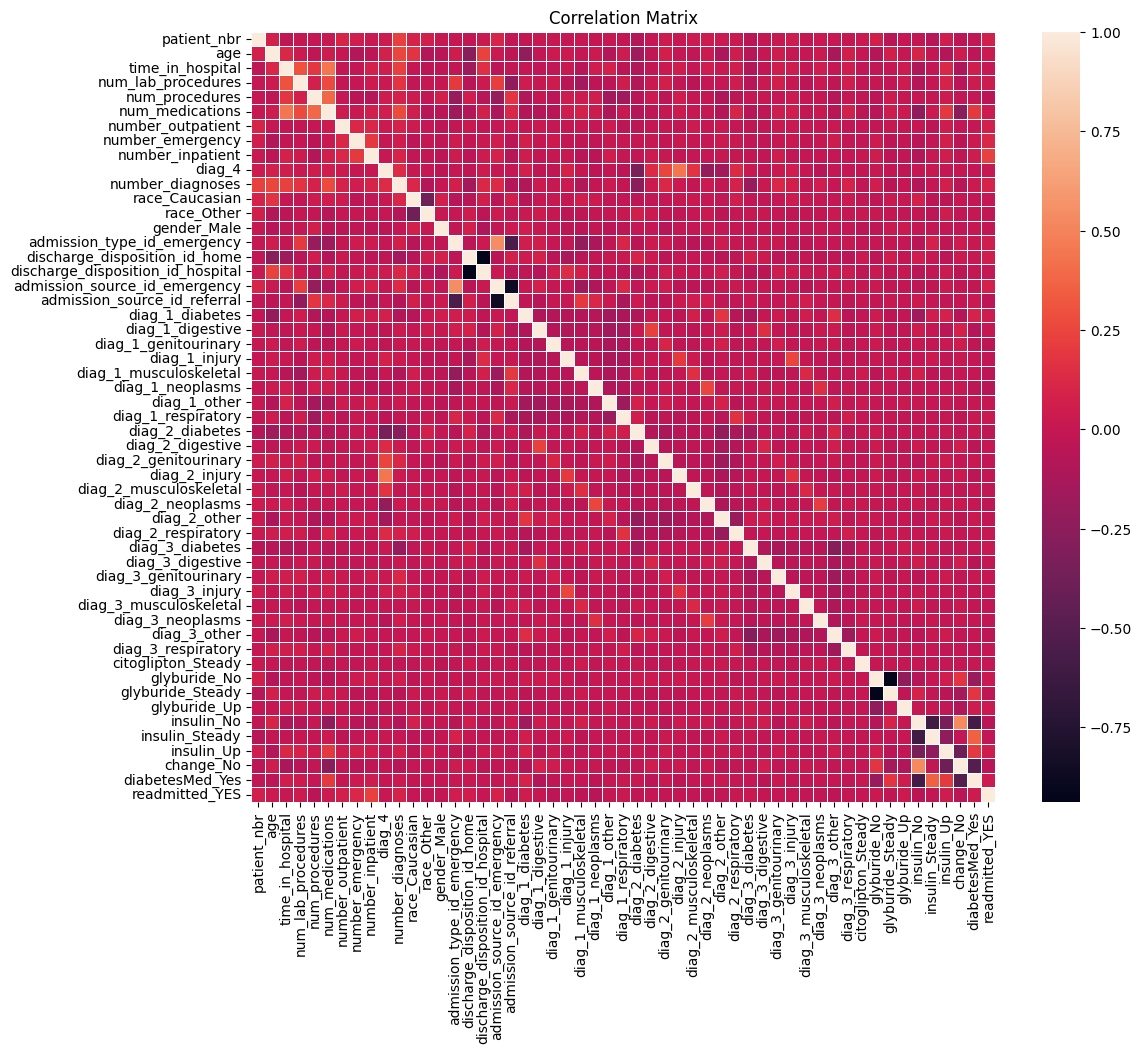

In [ ]:
plt.figure(figsize=(12, 10))  
sns.heatmap(df_extra.corr(), fmt=".2f", linewidths=0.5, annot=False, cbar=True, xticklabels=True, yticklabels=True, annot_kws={"size": 8})
plt.title("Correlation Matrix")
plt.show()

In [24]:
df_extra.to_csv('df_extra_dataset.csv', index=False)